# Factor Analysis of UA (User Acquisition) Features — Athler Dataset

**Goal**: Extract latent dimensions from 15 UA features for paid users to understand the underlying structure of ad journey data.

**Features (15)**:
- **Channel**: `trackinglink_count`, `DA_count`, `unique_channel_count`, `channel_entropy`, `last_touch_is_da`
- **Temporal**: `latency`, `recency`, `recent_touch_pressure`, `touch_per_latency_hour`, `last1h_touch_count`, `recent_24h_ratio`
- **Behavioral**: `click_ratio`, `impression_count`
- **Other**: `SA_count`, `is_single_touch_install`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis
from scipy.stats import pearsonr

# Varimax rotation implementation
def varimax(Phi, gamma=1.0, q=100, tol=1e-6):
    """Perform varimax rotation on a factor loading matrix."""
    p, k = Phi.shape
    R = np.eye(k)
    for _ in range(q):
        Lambda = Phi @ R
        u, s, vt = np.linalg.svd(
            Phi.T @ (Lambda**3 - (gamma / p) * Lambda @ np.diag(np.sum(Lambda**2, axis=0)))
        )
        R = u @ vt
        d = np.sum(s)
    return Phi @ R, R

# Publication-quality plot settings
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': False,
})

FEATURES = [
    'trackinglink_count', 'DA_count', 'unique_channel_count', 'channel_entropy', 'last_touch_is_da',
    'latency', 'recency', 'recent_touch_pressure', 'touch_per_latency_hour', 'last1h_touch_count', 'recent_24h_ratio',
    'click_ratio', 'impression_count',
    'SA_count', 'is_single_touch_install'
]

# Short labels for plots
LABELS = [
    'Tracking\nLinks', 'DA\nCount', 'Unique\nChannels', 'Channel\nEntropy', 'Last Touch\nis DA',
    'Latency', 'Recency', 'Recent Touch\nPressure', 'Touch/\nLatency Hr', 'Last 1h\nTouches', 'Recent 24h\nRatio',
    'Click\nRatio', 'Impression\nCount',
    'SA\nCount', 'Single Touch\nInstall'
]

print(f"Features selected: {len(FEATURES)}")

Features selected: 15


## 1. Data Preparation

In [2]:
# Load data and filter to paid users
df = pd.read_parquet('/Users/ab180/Desktop/David/Research/athler/athler_v1.parquet')
df_paid = df[df['has_touchpoint'] == 1].copy()
print(f"Total users: {len(df):,}")
print(f"Paid users (has_touchpoint=1): {len(df_paid):,}")

# Extract features
X_raw = df_paid[FEATURES].copy()
print(f"\nMissing values per feature:")
print(X_raw.isna().sum().to_string())

# Descriptive stats
print(f"\n{'='*80}")
print("Descriptive Statistics (raw)")
print('='*80)
X_raw.describe().round(3).T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

Total users: 53,699
Paid users (has_touchpoint=1): 48,884

Missing values per feature:
trackinglink_count         0
DA_count                   0
unique_channel_count       0
channel_entropy            0
last_touch_is_da           0
latency                    0
recency                    0
recent_touch_pressure      0
touch_per_latency_hour     0
last1h_touch_count         0
recent_24h_ratio           0
click_ratio                0
impression_count           0
SA_count                   0
is_single_touch_install    0

Descriptive Statistics (raw)


,mean,std,min,25%,50%,75%,max
trackinglink_count,4.678,6.638,0.000,1.000,3.000,6.000,1.020000e+02
DA_count,1.209,2.393,0.000,0.000,1.000,1.000,1.000000e+02
unique_channel_count,2.282,1.137,1.000,2.000,2.000,3.000,1.100000e+01
channel_entropy,0.669,0.391,0.000,0.469,0.865,0.954,1.000000e+00
last_touch_is_da,0.363,0.481,0.000,0.000,0.000,1.000,1.000000e+00
latency,402037.492,1439348.018,0.000,535.180,61133.333,499475.308,8.199358e+07
recency,22723.533,75689.976,0.000,23.123,164.287,2055.836,6.040503e+05
recent_touch_pressure,5.294,6.521,0.001,1.819,3.973,5.999,1.029590e+02
touch_per_latency_hour,1.326,1.869,0.000,0.063,0.300,2.000,6.721800e+01
last1h_touch_count,2.942,2.325,0.000,1.000,3.000,4.000,6.300000e+01


In [3]:
# Standardize features (z-score)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_raw),
    columns=FEATURES,
    index=X_raw.index
)

print("Standardized feature matrix shape:", X_scaled.shape)
print("\nVerification (mean ≈ 0, std ≈ 1):")
print(X_scaled.describe().loc[['mean', 'std']].round(4).T)

Standardized feature matrix shape: (48884, 15)

Verification (mean ≈ 0, std ≈ 1):
                         mean  std
trackinglink_count       -0.0  1.0
DA_count                 -0.0  1.0
unique_channel_count      0.0  1.0
channel_entropy          -0.0  1.0
last_touch_is_da         -0.0  1.0
latency                  -0.0  1.0
recency                   0.0  1.0
recent_touch_pressure    -0.0  1.0
touch_per_latency_hour   -0.0  1.0
last1h_touch_count       -0.0  1.0
recent_24h_ratio         -0.0  1.0
click_ratio               0.0  1.0
impression_count         -0.0  1.0
SA_count                 -0.0  1.0
is_single_touch_install   0.0  1.0


## 2. Suitability Tests & Determining Number of Factors

In [4]:
# Bartlett's test of sphericity (manual implementation)
n = X_scaled.shape[0]
p = X_scaled.shape[1]
corr = X_scaled.corr().values
det = np.linalg.det(corr)
chi_square = -((n - 1) - (2 * p + 5) / 6) * np.log(det)
df_bartlett = p * (p - 1) / 2
from scipy.stats import chi2
p_value = chi2.sf(chi_square, df_bartlett)

print(f"Bartlett's Test of Sphericity:")
print(f"  Chi-square = {chi_square:,.1f}")
print(f"  df         = {int(df_bartlett)}")
print(f"  p-value    = {p_value:.2e}")
print(f"  → {'PASS' if p_value < 0.05 else 'FAIL'}: correlation matrix is {'NOT' if p_value < 0.05 else ''} an identity matrix\n")

# KMO test (manual implementation)
corr_mat = X_scaled.corr().values
inv_corr = np.linalg.inv(corr_mat)
# Partial correlation matrix
D = np.diag(1.0 / np.sqrt(np.diag(inv_corr)))
partial_corr = -(D @ inv_corr @ D)
np.fill_diagonal(partial_corr, 0)
np.fill_diagonal(corr_mat, 0)

sum_corr_sq = np.sum(corr_mat ** 2)
sum_partial_sq = np.sum(partial_corr ** 2)
kmo_model = sum_corr_sq / (sum_corr_sq + sum_partial_sq)

# Per-feature KMO
kmo_per = np.zeros(p)
for j in range(p):
    r_sq = np.sum(corr_mat[j, :] ** 2)
    q_sq = np.sum(partial_corr[j, :] ** 2)
    kmo_per[j] = r_sq / (r_sq + q_sq) if (r_sq + q_sq) > 0 else 0

print(f"KMO (Kaiser-Meyer-Olkin) Test:")
print(f"  Overall KMO = {kmo_model:.4f}")
kmo_grade = (
    "Marvelous" if kmo_model >= 0.9 else
    "Meritorious" if kmo_model >= 0.8 else
    "Middling" if kmo_model >= 0.7 else
    "Mediocre" if kmo_model >= 0.6 else
    "Miserable" if kmo_model >= 0.5 else
    "Unacceptable"
)
print(f"  Grade: {kmo_grade}")
print(f"\n  Per-feature KMO:")
for feat, val in zip(FEATURES, kmo_per):
    flag = " ⚠" if val < 0.5 else ""
    print(f"    {feat:30s} {val:.4f}{flag}")

Bartlett's Test of Sphericity:
  Chi-square = 334,609.0
  df         = 105
  p-value    = 0.00e+00
  → PASS: correlation matrix is NOT an identity matrix

KMO (Kaiser-Meyer-Olkin) Test:
  Overall KMO = 0.5417
  Grade: Miserable

  Per-feature KMO:
    trackinglink_count             0.4701 ⚠
    DA_count                       0.2548 ⚠
    unique_channel_count           0.7554
    channel_entropy                0.6127
    last_touch_is_da               0.4967 ⚠
    latency                        0.6561
    recency                        0.2157 ⚠
    recent_touch_pressure          0.4964 ⚠
    touch_per_latency_hour         0.6589
    last1h_touch_count             0.8029
    recent_24h_ratio               0.6830
    click_ratio                    0.5430
    impression_count               0.5386
    SA_count                       0.1877 ⚠
    is_single_touch_install        0.6434


In [5]:
# PCA for eigenvalue analysis
pca = PCA(n_components=len(FEATURES))
pca.fit(X_scaled)

eigenvalues = pca.explained_variance_
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Parallel Analysis: generate random data with same dimensions, compute eigenvalues
np.random.seed(42)
n_iter = 100
random_eigenvalues = np.zeros((n_iter, len(FEATURES)))
for i in range(n_iter):
    random_data = np.random.normal(size=X_scaled.shape)
    random_pca = PCA(n_components=len(FEATURES))
    random_pca.fit(random_data)
    random_eigenvalues[i] = random_pca.explained_variance_

parallel_threshold = np.percentile(random_eigenvalues, 95, axis=0)

# Print eigenvalue table
print(f"{'Component':>10} {'Eigenvalue':>12} {'% Variance':>12} {'Cumulative %':>14} {'Parallel 95%':>14} {'Retain?':>8}")
print("-" * 75)
n_factors_kaiser = 0
n_factors_parallel = 0
for i in range(len(FEATURES)):
    kaiser = eigenvalues[i] > 1.0
    parallel = eigenvalues[i] > parallel_threshold[i]
    if kaiser: n_factors_kaiser = i + 1
    if parallel: n_factors_parallel = i + 1
    retain = "Yes" if (kaiser and parallel) else ("Kaiser" if kaiser else ("Parallel" if parallel else ""))
    print(f"{i+1:>10} {eigenvalues[i]:>12.4f} {explained_var[i]*100:>11.2f}% {cumulative_var[i]*100:>13.2f}% {parallel_threshold[i]:>14.4f} {retain:>8}")

print(f"\nKaiser criterion (eigenvalue > 1): {n_factors_kaiser} factors")
print(f"Parallel analysis (95th pctl):    {n_factors_parallel} factors")

 Component   Eigenvalue   % Variance   Cumulative %   Parallel 95%  Retain?
---------------------------------------------------------------------------
         1       3.4677       23.12%         23.12%         1.0373      Yes
         2       2.1602       14.40%         37.52%         1.0294      Yes
         3       1.7561       11.71%         49.23%         1.0240      Yes
         4       1.3594        9.06%         58.29%         1.0196      Yes
         5       1.3002        8.67%         66.96%         1.0155      Yes
         6       1.0179        6.79%         73.74%         1.0112      Yes
         7       0.9635        6.42%         80.16%         1.0079         
         8       0.7356        4.90%         85.07%         1.0040         
         9       0.6350        4.23%         89.30%         1.0005         
        10       0.4507        3.00%         92.31%         0.9962         
        11       0.3185        2.12%         94.43%         0.9926         
        12  

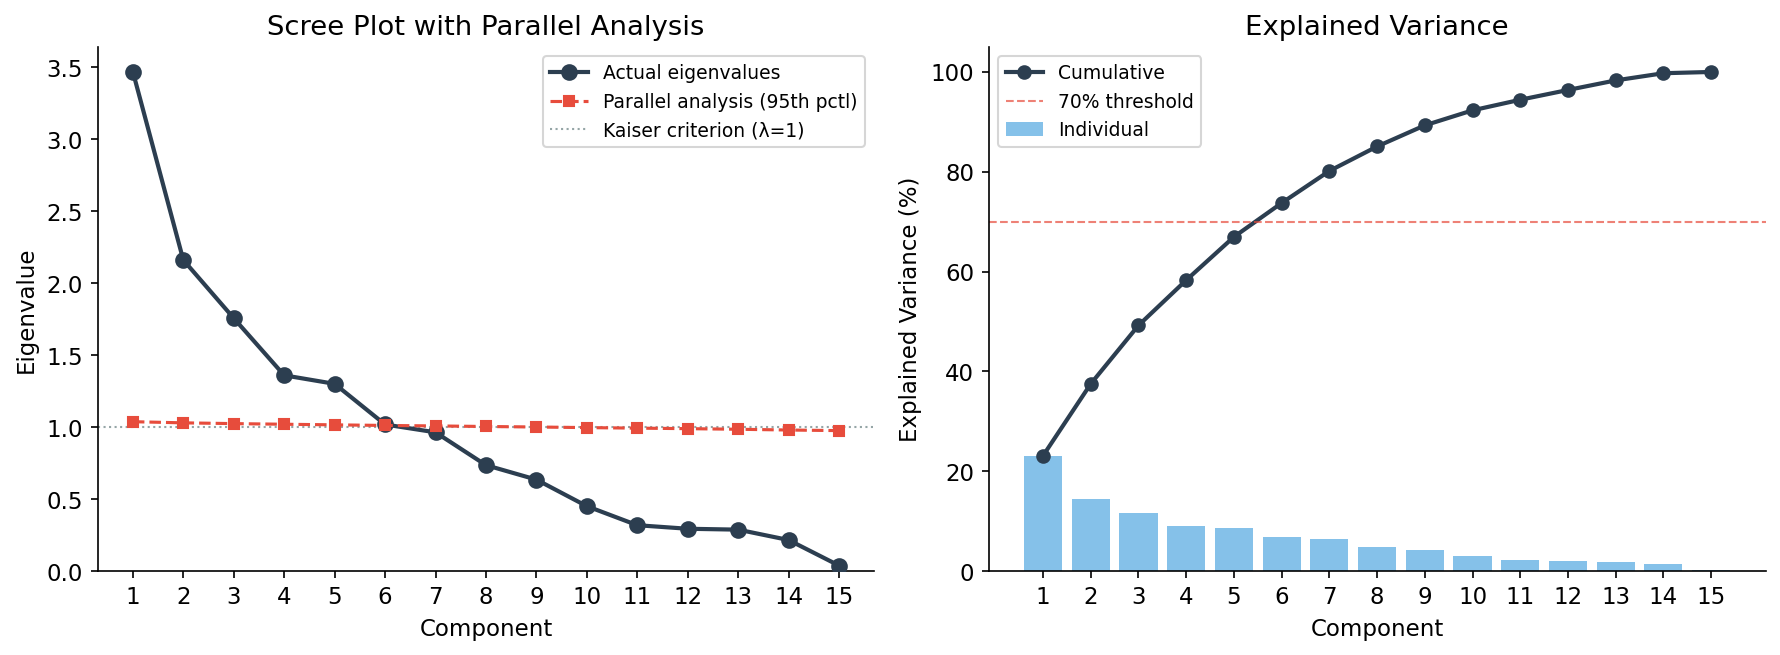


→ Recommended number of factors: 6 (parallel analysis)


In [6]:
# Scree Plot with Parallel Analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: Scree plot
ax = axes[0]
components = np.arange(1, len(FEATURES) + 1)
ax.plot(components, eigenvalues, 'o-', color='#2C3E50', linewidth=2, markersize=7, label='Actual eigenvalues', zorder=3)
ax.plot(components, parallel_threshold, 's--', color='#E74C3C', linewidth=1.5, markersize=5, label='Parallel analysis (95th pctl)', zorder=3)
ax.axhline(y=1.0, color='#95A5A6', linestyle=':', linewidth=1, label='Kaiser criterion (λ=1)')
ax.set_xlabel('Component')
ax.set_ylabel('Eigenvalue')
ax.set_title('Scree Plot with Parallel Analysis')
ax.set_xticks(components)
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(bottom=0)

# Right: Cumulative variance
ax = axes[1]
ax.bar(components, explained_var * 100, color='#3498DB', alpha=0.6, label='Individual')
ax.plot(components, cumulative_var * 100, 'o-', color='#2C3E50', linewidth=2, markersize=6, label='Cumulative')
ax.axhline(y=70, color='#E74C3C', linestyle='--', linewidth=1, alpha=0.7, label='70% threshold')
ax.set_xlabel('Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Explained Variance')
ax.set_xticks(components)
ax.legend(fontsize=9)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('/Users/ab180/Desktop/David/Research/athler/fa_scree_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n→ Recommended number of factors: {n_factors_parallel} (parallel analysis)")

## 3. Factor Analysis (Varimax Rotation)

In [7]:
# Run Factor Analysis using sklearn + varimax rotation
n_factors = n_factors_parallel
print(f"Fitting Factor Analysis with {n_factors} factors (varimax rotation)\n")

# Fit sklearn FactorAnalysis (MLE)
fa = FactorAnalysis(n_components=n_factors, random_state=42)
fa.fit(X_scaled)

# Get unrotated loadings (components_ is n_factors x n_features)
unrotated_loadings = fa.components_.T  # shape: (n_features, n_factors)

# Apply varimax rotation
rotated_loadings, rotation_matrix = varimax(unrotated_loadings)

loadings = pd.DataFrame(
    rotated_loadings,
    index=FEATURES,
    columns=[f'Factor {i+1}' for i in range(n_factors)]
)

# Compute variance explained by each factor (SS loadings)
ss_loadings = (rotated_loadings ** 2).sum(axis=0)
prop_var = ss_loadings / len(FEATURES)
cum_var = np.cumsum(prop_var)

variance_df = pd.DataFrame({
    'SS Loadings': ss_loadings,
    'Proportion Var': prop_var,
    'Cumulative Var': cum_var,
}, index=[f'Factor {i+1}' for i in range(n_factors)])

print("Variance Explained by Each Factor:")
print(variance_df.round(4).to_string())
print(f"\nTotal variance explained: {cum_var[-1]*100:.1f}%")

# Communalities
communalities_vals = (rotated_loadings ** 2).sum(axis=1)
communalities = pd.DataFrame({
    'Feature': FEATURES,
    'Communality': communalities_vals
}).set_index('Feature')
print(f"\nCommunalities (proportion of variance explained by factors):")
print(communalities.round(4).to_string())

Fitting Factor Analysis with 6 factors (varimax rotation)



Variance Explained by Each Factor:
          SS Loadings  Proportion Var  Cumulative Var
Factor 1       2.5083          0.1672          0.1672
Factor 2       1.1834          0.0789          0.2461
Factor 3       1.4654          0.0977          0.3438
Factor 4       1.7622          0.1175          0.4613
Factor 5       1.4978          0.0999          0.5611
Factor 6       0.4807          0.0320          0.5932

Total variance explained: 59.3%

Communalities (proportion of variance explained by factors):
                         Communality
Feature                             
trackinglink_count            0.9974
DA_count                      0.8728
unique_channel_count          0.6746
channel_entropy               0.8438
last_touch_is_da              0.2130
latency                       0.1328
recency                       0.4497
recent_touch_pressure         0.9969
touch_per_latency_hour        0.4258
last1h_touch_count            0.5662
recent_24h_ratio              0.7507
click_ratio

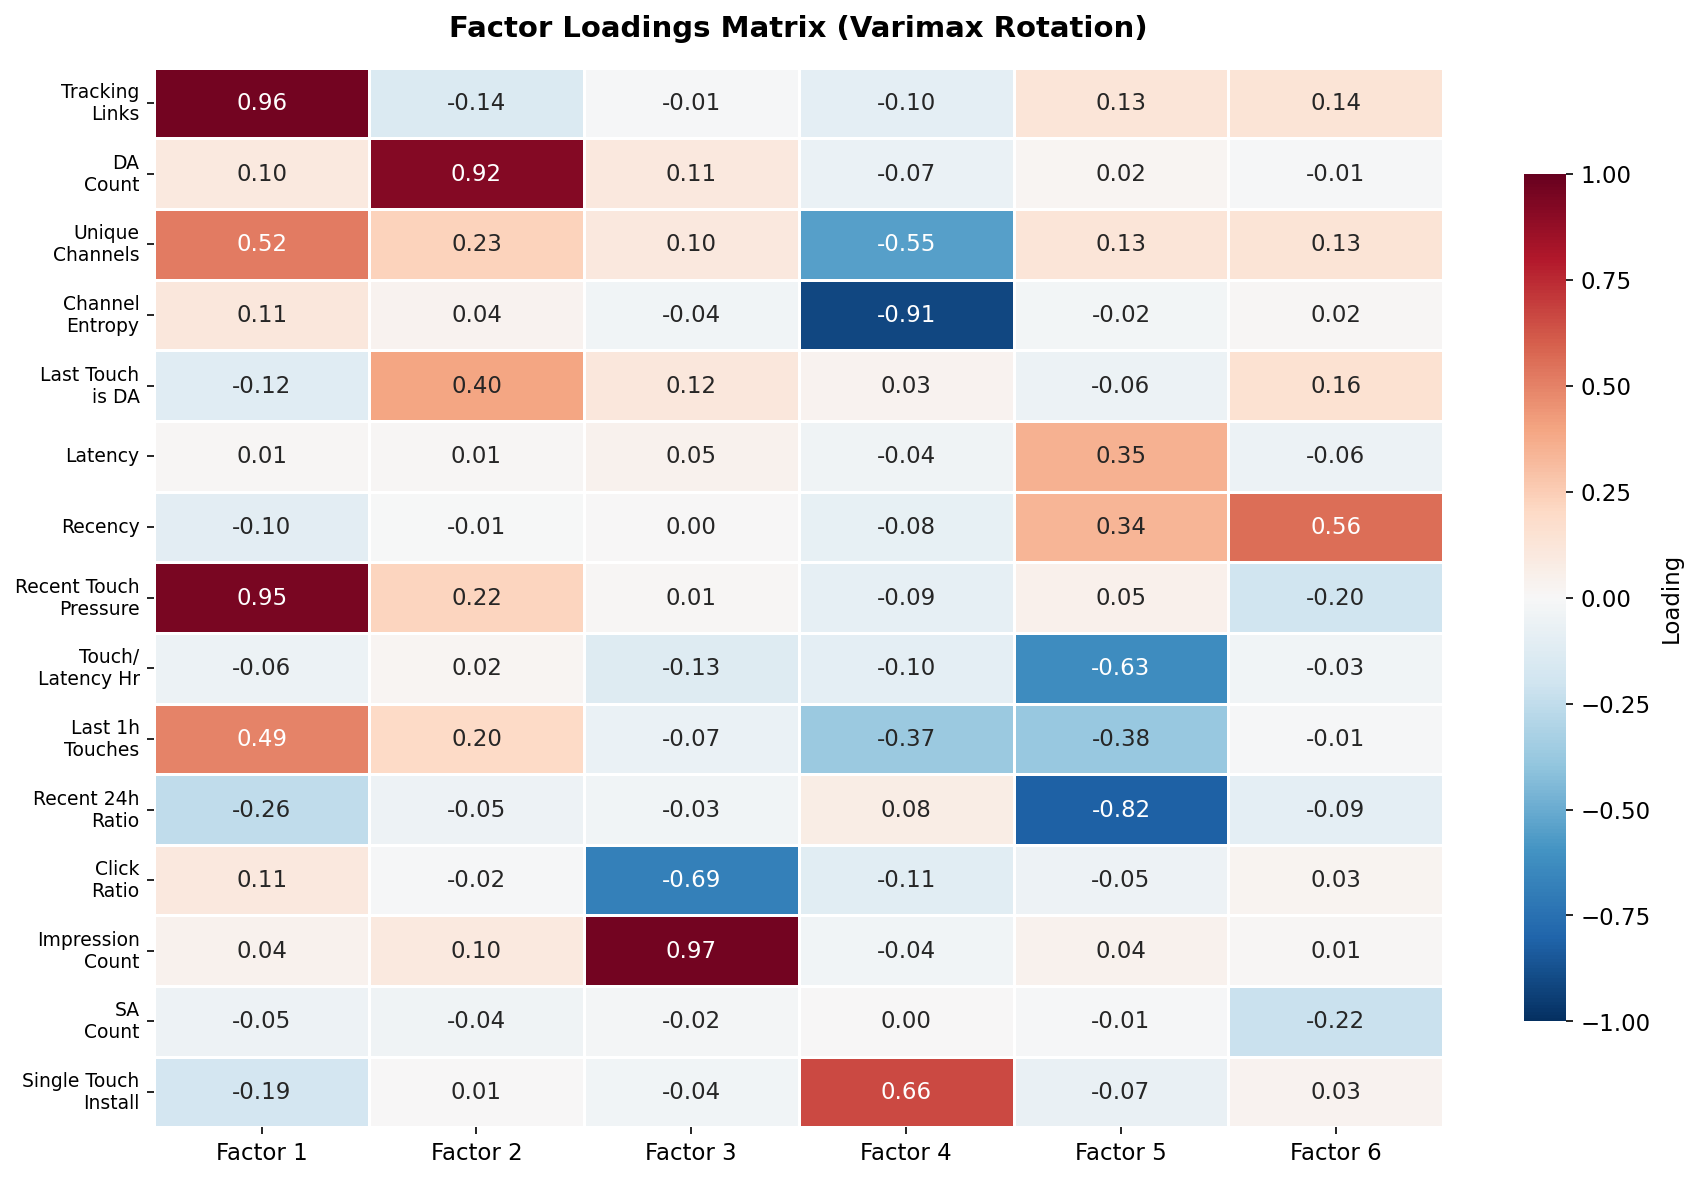

In [8]:
# Factor Loadings Heatmap
fig, ax = plt.subplots(figsize=(max(8, n_factors * 2), 8))

# Create annotated heatmap
loadings_display = loadings.copy()
loadings_display.index = LABELS

sns.heatmap(
    loadings_display,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Loading', 'shrink': 0.8},
    ax=ax
)
ax.set_title('Factor Loadings Matrix (Varimax Rotation)', fontsize=14, fontweight='bold', pad=15)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)

plt.tight_layout()
plt.savefig('/Users/ab180/Desktop/David/Research/athler/fa_loadings_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Factor Interpretation

In [9]:
# Identify top-loading features per factor (|loading| > 0.3)
THRESHOLD = 0.3

print("=" * 80)
print("FACTOR INTERPRETATION SUMMARY")
print("=" * 80)

factor_summary = {}
for col in loadings.columns:
    top = loadings[col].abs().sort_values(ascending=False)
    significant = top[top >= THRESHOLD]
    
    print(f"\n{col}:")
    print(f"  Variance explained: {variance_df.loc[col, 'Proportion Var']*100:.1f}%")
    print(f"  Top features (|loading| >= {THRESHOLD}):")
    for feat in significant.index:
        val = loadings.loc[feat, col]
        direction = "+" if val > 0 else "-"
        print(f"    {direction} {feat:30s} {val:+.3f}")
    
    factor_summary[col] = list(significant.index)

# Create structured summary table
print("\n" + "=" * 80)
print("FACTOR-FEATURE ASSIGNMENT (highest absolute loading)")
print("=" * 80)

assignment = loadings.abs().idxmax(axis=1)
for feat in FEATURES:
    factor = assignment[feat]
    val = loadings.loc[feat, factor]
    print(f"  {feat:30s} → {factor} ({val:+.3f})")

FACTOR INTERPRETATION SUMMARY

Factor 1:
  Variance explained: 16.7%
  Top features (|loading| >= 0.3):
    + trackinglink_count             +0.965
    + recent_touch_pressure          +0.947
    + unique_channel_count           +0.521
    + last1h_touch_count             +0.493

Factor 2:
  Variance explained: 7.9%
  Top features (|loading| >= 0.3):
    + DA_count                       +0.920
    + last_touch_is_da               +0.395

Factor 3:
  Variance explained: 9.8%
  Top features (|loading| >= 0.3):
    + impression_count               +0.965
    - click_ratio                    -0.685

Factor 4:
  Variance explained: 11.7%
  Top features (|loading| >= 0.3):
    - channel_entropy                -0.910
    + is_single_touch_install        +0.658
    - unique_channel_count           -0.550
    - last1h_touch_count             -0.370

Factor 5:
  Variance explained: 10.0%
  Top features (|loading| >= 0.3):
    - recent_24h_ratio               -0.817
    - touch_per_latency_hour  

## 5. Validation: Factor Scores vs. Outcomes

In [10]:
# Compute factor scores using sklearn transform + rotation
raw_scores = fa.transform(X_scaled)  # unrotated scores
# Apply rotation to scores
factor_scores_arr = raw_scores @ rotation_matrix

factor_scores = pd.DataFrame(
    factor_scores_arr,
    columns=[f'Factor {i+1}' for i in range(n_factors)],
    index=X_scaled.index
)

# Attach outcomes
outcomes = ['IS_D7_PURCHASE', 'IS_D1_PURCHASE', 'IS_M10_CHURN', 'IS_D7_CHURN']
for col in outcomes:
    factor_scores[col] = df_paid[col].values

print("Factor score statistics:")
print(factor_scores[[f'Factor {i+1}' for i in range(n_factors)]].describe().round(3).T)
print(f"\nOutcome rates:")
for col in outcomes:
    print(f"  {col}: {factor_scores[col].mean()*100:.1f}%")

Factor score statistics:
            count  mean    std     min    25%    50%    75%     max
Factor 1  48884.0  -0.0  0.997  -1.508 -0.491 -0.209  0.079  15.778
Factor 2  48884.0  -0.0  0.947  -5.574 -0.490 -0.201  0.193  38.323
Factor 3  48884.0   0.0  0.973  -3.871 -0.336 -0.281 -0.241  27.837
Factor 4  48884.0   0.0  0.934  -1.670 -0.666 -0.473  0.834   4.208
Factor 5  48884.0   0.0  0.888 -12.763 -0.575 -0.239  0.517   7.355
Factor 6  48884.0   0.0  0.915 -20.141 -0.378 -0.120  0.088  21.408

Outcome rates:
  IS_D7_PURCHASE: 25.4%
  IS_D1_PURCHASE: 19.7%
  IS_M10_CHURN: 20.4%
  IS_D7_CHURN: 37.9%


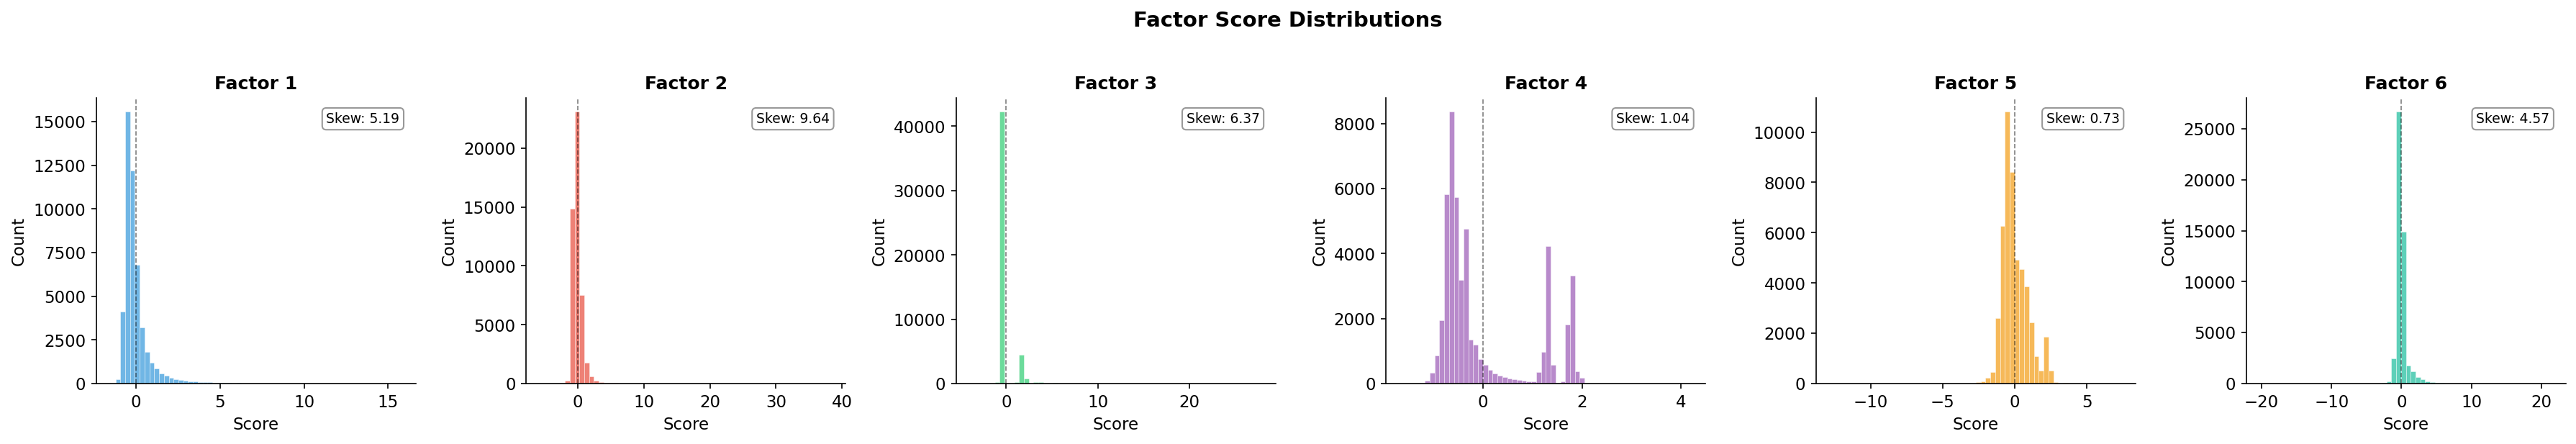

In [11]:
# Factor score distributions
fig, axes = plt.subplots(1, n_factors, figsize=(4 * n_factors, 4))
if n_factors == 1:
    axes = [axes]

colors = ['#3498DB', '#E74C3C', '#2ECC71', '#9B59B6', '#F39C12', '#1ABC9C', '#E67E22']

for i, ax in enumerate(axes):
    col = f'Factor {i+1}'
    ax.hist(factor_scores[col], bins=60, color=colors[i % len(colors)], alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    
    # Add skewness annotation
    skew = factor_scores[col].skew()
    ax.text(0.95, 0.95, f'Skew: {skew:.2f}', transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

plt.suptitle('Factor Score Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/Users/ab180/Desktop/David/Research/athler/fa_score_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

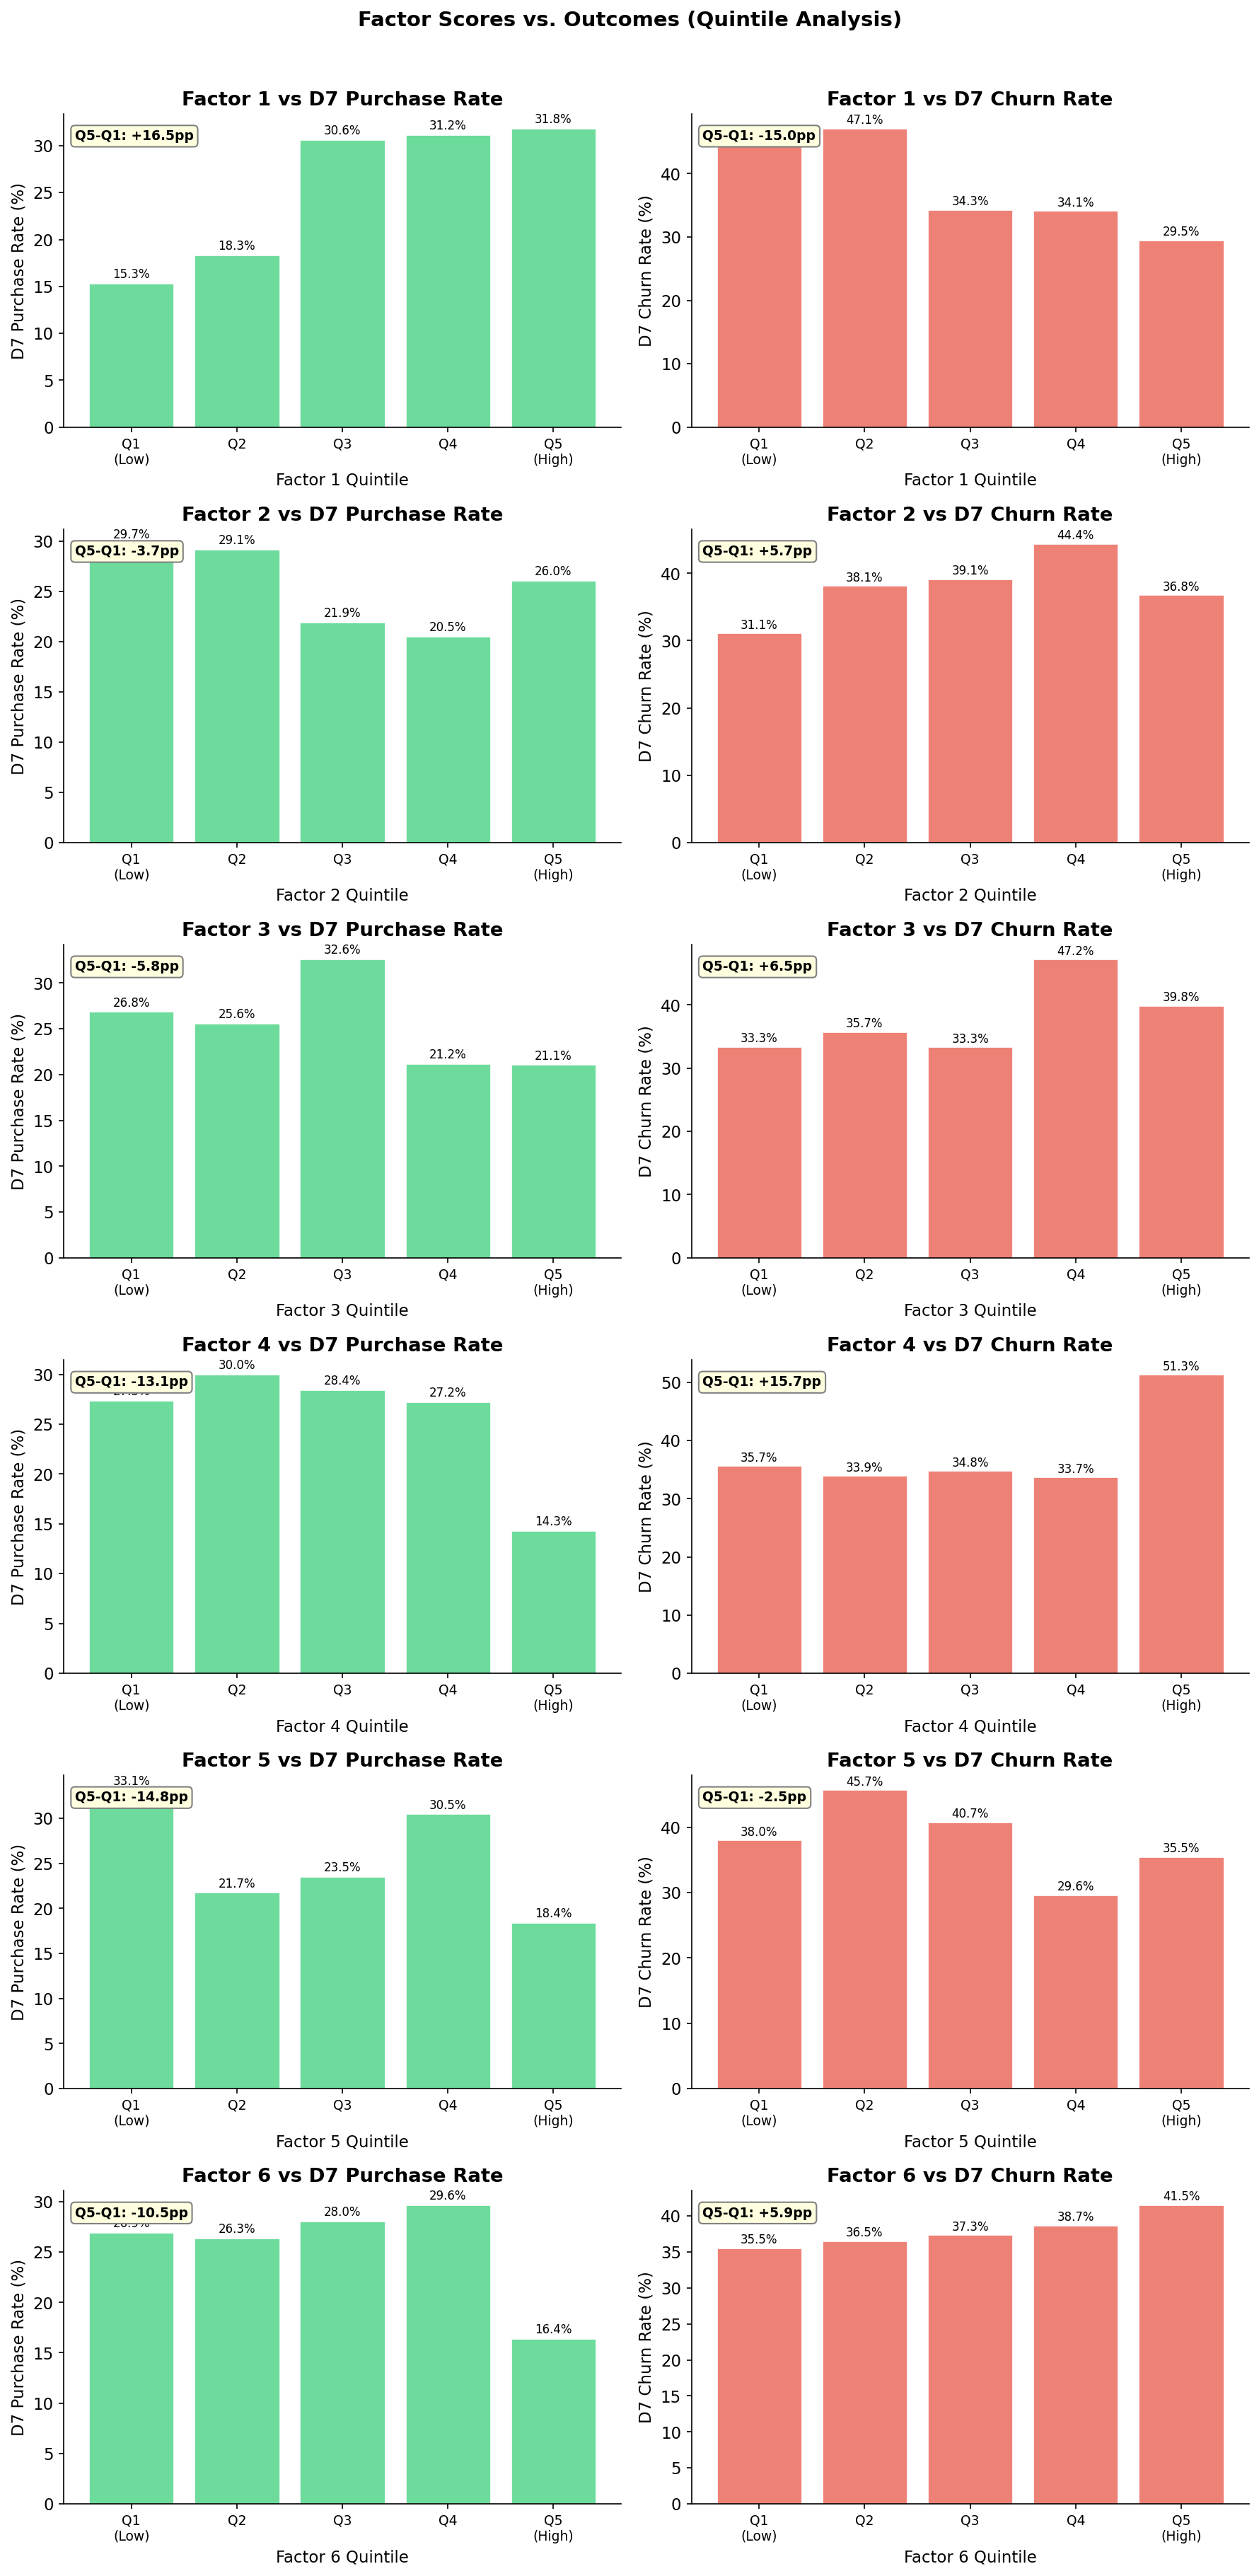

In [12]:
# Factor scores vs outcomes: quintile analysis
fig, axes = plt.subplots(n_factors, 2, figsize=(12, 4 * n_factors))
if n_factors == 1:
    axes = axes.reshape(1, -1)

outcome_labels = {'IS_D7_PURCHASE': 'D7 Purchase Rate', 'IS_D7_CHURN': 'D7 Churn Rate'}
outcome_colors = {'IS_D7_PURCHASE': '#2ECC71', 'IS_D7_CHURN': '#E74C3C'}

for i in range(n_factors):
    factor_col = f'Factor {i+1}'
    
    # Create quintiles
    factor_scores[f'{factor_col}_Q'] = pd.qcut(factor_scores[factor_col], 5, labels=['Q1\n(Low)', 'Q2', 'Q3', 'Q4', 'Q5\n(High)'], duplicates='drop')
    
    for j, (outcome, label) in enumerate(outcome_labels.items()):
        ax = axes[i, j]
        quintile_means = factor_scores.groupby(f'{factor_col}_Q', observed=True)[outcome].mean() * 100
        
        bars = ax.bar(range(len(quintile_means)), quintile_means.values, 
                       color=outcome_colors[outcome], alpha=0.7, edgecolor='white', linewidth=0.5)
        ax.set_xticks(range(len(quintile_means)))
        ax.set_xticklabels(quintile_means.index, fontsize=9)
        ax.set_ylabel(f'{label} (%)')
        ax.set_xlabel(f'{factor_col} Quintile')
        ax.set_title(f'{factor_col} vs {label}', fontweight='bold')
        
        # Add value labels on bars
        for bar_idx, bar in enumerate(bars):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=8)
        
        # Compute Q5-Q1 spread
        if len(quintile_means) >= 2:
            spread = quintile_means.iloc[-1] - quintile_means.iloc[0]
            ax.text(0.02, 0.95, f'Q5-Q1: {spread:+.1f}pp', transform=ax.transAxes,
                    ha='left', va='top', fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))
    
    # Drop temp column
    factor_scores.drop(columns=[f'{factor_col}_Q'], inplace=True)

plt.suptitle('Factor Scores vs. Outcomes (Quintile Analysis)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/Users/ab180/Desktop/David/Research/athler/fa_scores_vs_outcomes.png', dpi=300, bbox_inches='tight')
plt.show()

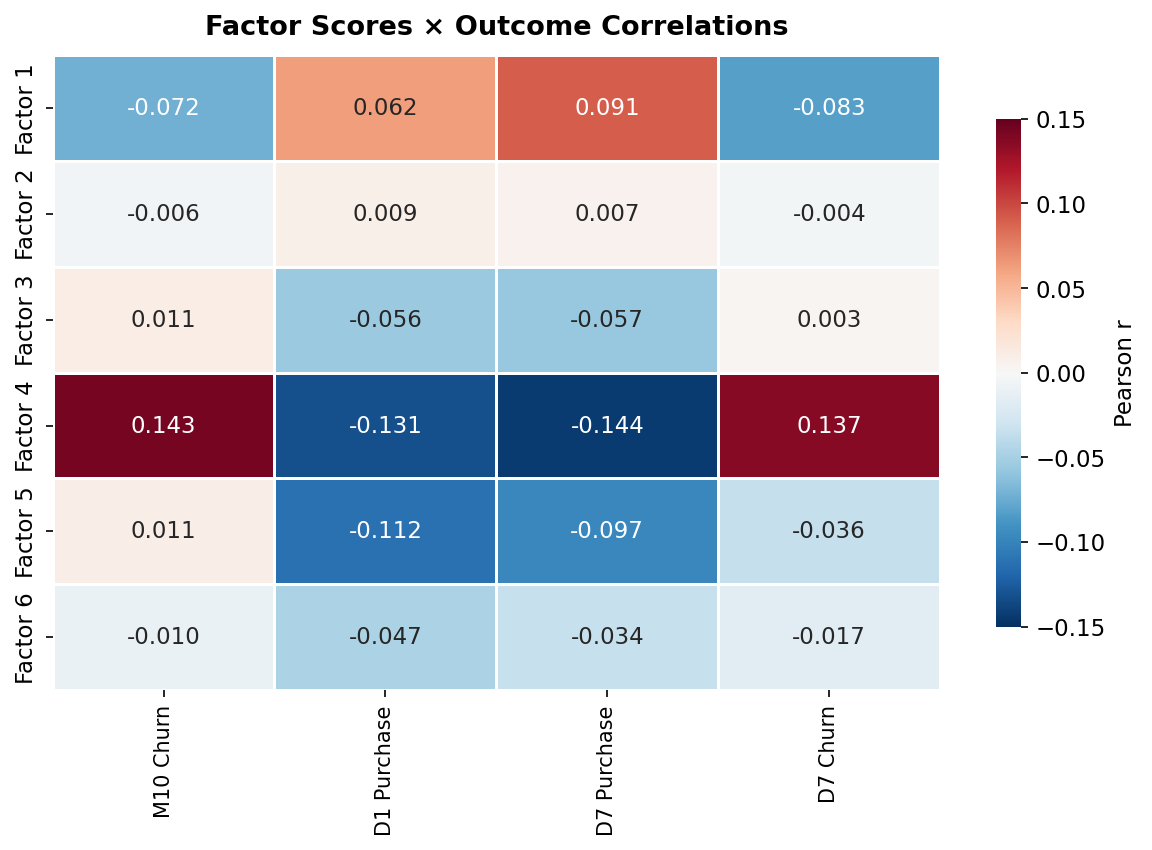


Statistical significance (p-values):
  Factor 1 × IS_M10_CHURN        : r=-0.0721, p=2.24e-57 ***
  Factor 1 × IS_D1_PURCHASE      : r=+0.0625, p=1.73e-43 ***
  Factor 1 × IS_D7_PURCHASE      : r=+0.0906, p=1.54e-89 ***
  Factor 1 × IS_D7_CHURN         : r=-0.0829, p=2.72e-75 ***
  Factor 2 × IS_M10_CHURN        : r=-0.0056, p=2.12e-01 
  Factor 2 × IS_D1_PURCHASE      : r=+0.0093, p=3.95e-02 *
  Factor 2 × IS_D7_PURCHASE      : r=+0.0068, p=1.32e-01 
  Factor 2 × IS_D7_CHURN         : r=-0.0040, p=3.78e-01 
  Factor 3 × IS_M10_CHURN        : r=+0.0107, p=1.81e-02 *
  Factor 3 × IS_D1_PURCHASE      : r=-0.0558, p=4.83e-35 ***
  Factor 3 × IS_D7_PURCHASE      : r=-0.0574, p=5.82e-37 ***
  Factor 3 × IS_D7_CHURN         : r=+0.0034, p=4.55e-01 
  Factor 4 × IS_M10_CHURN        : r=+0.1432, p=3.17e-222 ***
  Factor 4 × IS_D1_PURCHASE      : r=-0.1314, p=3.51e-187 ***
  Factor 4 × IS_D7_PURCHASE      : r=-0.1438, p=3.89e-224 ***
  Factor 4 × IS_D7_CHURN         : r=+0.1368, p=8.07e-203 **

In [13]:
# Correlation between factor scores and multiple outcomes
outcome_cols = ['IS_M10_CHURN', 'IS_D1_PURCHASE', 'IS_D7_PURCHASE', 'IS_D7_CHURN']
factor_cols = [f'Factor {i+1}' for i in range(n_factors)]

corr_matrix = factor_scores[factor_cols + outcome_cols].corr().loc[factor_cols, outcome_cols]

fig, ax = plt.subplots(figsize=(8, max(3, n_factors * 0.8 + 1)))
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f',
    cmap='RdBu_r', center=0, vmin=-0.15, vmax=0.15,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Pearson r', 'shrink': 0.8},
    ax=ax
)
ax.set_title('Factor Scores × Outcome Correlations', fontsize=13, fontweight='bold', pad=10)
ax.set_xticklabels(['M10 Churn', 'D1 Purchase', 'D7 Purchase', 'D7 Churn'], fontsize=10)
plt.tight_layout()
plt.savefig('/Users/ab180/Desktop/David/Research/athler/fa_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nStatistical significance (p-values):")
from scipy.stats import pearsonr
for fc in factor_cols:
    for oc in outcome_cols:
        r, p = pearsonr(factor_scores[fc], factor_scores[oc])
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        print(f"  {fc} × {oc:20s}: r={r:+.4f}, p={p:.2e} {sig}")

## 6. Summary

In [14]:
# Final summary: loadings table sorted by dominant factor
print("=" * 90)
print("FINAL FACTOR LOADINGS TABLE (sorted by dominant factor)")
print("=" * 90)

# For each feature, find its dominant factor and loading
summary_rows = []
for feat in FEATURES:
    row = loadings.loc[feat]
    dominant = row.abs().idxmax()
    dominant_val = row[dominant]
    summary_rows.append({
        'Feature': feat,
        'Dominant Factor': dominant,
        'Loading': dominant_val,
        **{col: row[col] for col in loadings.columns}
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(['Dominant Factor', 'Loading'], ascending=[True, False])
summary_df = summary_df.reset_index(drop=True)

# Print with formatting
for factor_name in sorted(summary_df['Dominant Factor'].unique()):
    subset = summary_df[summary_df['Dominant Factor'] == factor_name]
    print(f"\n  {factor_name}:")
    for _, row in subset.iterrows():
        loadings_str = "  ".join([f"{row[c]:+.3f}" for c in loadings.columns])
        print(f"    {row['Feature']:30s} [{loadings_str}]")

print(f"\n{'='*90}")
print(f"Total variance explained: {variance_df['Cumulative Var'].iloc[-1]*100:.1f}%")
print(f"Method: Maximum Likelihood with Varimax rotation")
print(f"N = {len(X_scaled):,} paid users, {len(FEATURES)} features, {n_factors} factors")
print(f"{'='*90}")

FINAL FACTOR LOADINGS TABLE (sorted by dominant factor)

  Factor 1:
    trackinglink_count             [+0.965  -0.142  -0.013  -0.100  +0.131  +0.139]
    recent_touch_pressure          [+0.947  +0.223  +0.012  -0.090  +0.050  -0.198]
    last1h_touch_count             [+0.493  +0.199  -0.066  -0.370  -0.378  -0.013]

  Factor 2:
    DA_count                       [+0.100  +0.920  +0.107  -0.069  +0.022  -0.010]
    last_touch_is_da               [-0.120  +0.395  +0.117  +0.032  -0.059  +0.155]

  Factor 3:
    impression_count               [+0.043  +0.101  +0.965  -0.037  +0.041  +0.014]
    click_ratio                    [+0.106  -0.015  -0.685  -0.112  -0.051  +0.029]

  Factor 4:
    is_single_touch_install        [-0.187  +0.007  -0.039  +0.658  -0.074  +0.031]
    unique_channel_count           [+0.521  +0.234  +0.105  -0.550  +0.130  +0.134]
    channel_entropy                [+0.110  +0.035  -0.035  -0.910  -0.025  +0.015]

  Factor 5:
    latency                        [+0.